# Music Emotion Recognition using CRNN Regression (PyTorch)
## DEAM Dataset — Predicting Valence & Arousal

This notebook builds a **CRNN (CNN + GRU)** regression model to predict **valence** and **arousal** 
values from audio, using **mel-spectrograms + chroma features** as input.

### Pipeline:
1. Load & merge DEAM dynamic (per-second) annotations
2. Extract mel-spectrograms from audio files
3. Build a CRNN regression model (CNN feature extractor + Bidirectional GRU) in PyTorch
4. Train with MSE loss
5. Evaluate with regression metrics (MSE, MAE, R², CCC)
6. Visualize predictions on the valence-arousal plane


## 1. Setup & Imports

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print("All libraries imported successfully!")


Using device: cuda
PyTorch version: 2.10.0+cu128
All libraries imported successfully!


In [4]:
# Mencari nama folder dataset pertama yang ada di /kaggle/input/
input_folders = os.listdir('/kaggle/input')
if input_folders:
    BASE_DIR = os.path.join('/kaggle/input', input_folders[0])
    print(f"BASE_DIR otomatis: {BASE_DIR}")

BASE_DIR otomatis: /kaggle/input/datasets


## 2. Load DEAM Dynamic Annotations

In [5]:
# === Dataset Paths ===
BASE_DIR = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music"
AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")

# Path to dynamic (per-second) annotations
DYN_ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
                             "annotations averaged per song", "dynamic (per second annotations)")

# --- Load dynamic annotation CSVs ---
arousal_file = os.path.join(DYN_ANNOT_DIR, "arousal.csv")
valence_file = os.path.join(DYN_ANNOT_DIR, "valence.csv")

if os.path.exists(arousal_file) and os.path.exists(valence_file):
    df_arousal = pd.read_csv(arousal_file)
    df_valence = pd.read_csv(valence_file)

    # Set song_id as index
    df_arousal = df_arousal.set_index('song_id')
    df_valence = df_valence.set_index('song_id')

    # Find song_ids present in both files
    common_songs = df_arousal.index.intersection(df_valence.index)

    df_arousal = df_arousal.loc[common_songs]
    df_valence = df_valence.loc[common_songs]

    print("\u2705 Dynamic annotations loaded successfully!")
    print(f"Total annotated songs (dynamic): {len(common_songs)}")
    display(df_arousal.head(3))
else:
    print("\u274c ERROR: Dynamic annotation CSV files not found. Check paths:")
    print(arousal_file)
    print(valence_file)


✅ Dynamic annotations loaded successfully!
Total annotated songs (dynamic): 1802


,sample_15000ms,sample_15500ms,sample_16000ms,sample_16500ms,sample_17000ms,sample_17500ms,sample_18000ms,sample_18500ms,sample_19000ms,sample_19500ms,...,sample_622000ms,sample_622500ms,sample_623000ms,sample_623500ms,sample_624000ms,sample_624500ms,sample_625000ms,sample_625500ms,sample_626000ms,sample_626500ms
song_id,,,,,,,,,,,,,,,,,,,,,
2,-0.109386,-0.114942,-0.116413,-0.118613,-0.126457,-0.133199,-0.136855,-0.144713,-0.138985,-0.137602,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.110846,-0.123973,-0.131103,-0.135956,-0.140775,-0.144664,-0.163118,-0.165218,-0.158858,-0.156783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.222327,0.179446,0.178388,0.184056,0.176042,0.178720,0.176345,0.175793,0.176154,0.176604,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Match Audio Files with Annotations

In [6]:
# Find available audio files
audio_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.mp3') or f.endswith('.wav')]
audio_ids = set()
for f in audio_files:
    try:
        song_id = int(f.split('.')[0])
        audio_ids.add(song_id)
    except ValueError:
        continue

print(f"Total audio files found: {len(audio_ids)}")

# Filter annotations to only include songs with audio
common_audio_songs = list(common_songs.intersection(audio_ids))
df_arousal = df_arousal.loc[common_audio_songs]
df_valence = df_valence.loc[common_audio_songs]

print(f"Annotated songs with audio (dynamic): {len(common_audio_songs)}")

# Convert the dynamic dataframe to numpy arrays for easier indexing later
# Bentuk: (N_songs, T_annotations), misal (1800, 30) untuk detik ke 15-45.
# Kolom biasanya berupa string waktu atau miripnya, kita ambil nilai numerik saja
arousal_array = df_arousal.values
valence_array = df_valence.values

# Pastikan mereka memilki shape yang sama
print(f"Arousal shape: {arousal_array.shape}, Valence shape: {valence_array.shape}")


Total audio files found: 1802
Annotated songs with audio (dynamic): 1802
Arousal shape: (1802, 1224), Valence shape: (1802, 1223)


## 4. Extract Mel-Spectrograms from Audio

We extract **2-channel features** (log-mel-spectrogram + chroma) which capture both
timbral and tonal information — important for predicting both arousal and valence.

Extracting features (mel + chroma) to disk (or finding existing ones)...


Extracting: 100%|██████████| 1802/1802 [10:21<00:00,  2.90it/s]



Extracted/Found 1802 mel-spectrograms.

Valid dataset size: 1802 songs


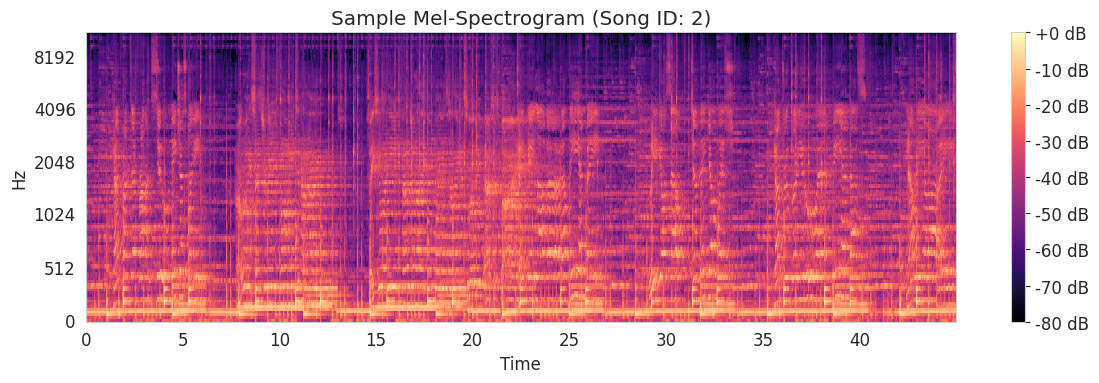

In [7]:
# === Mel-spectrogram extraction parameters ===
SR = 22050          # Sample rate
DURATION = 45       # Crop duration in seconds 
N_MELS = 128        # Number of mel bands
HOP_LENGTH = 512    # Hop length
N_FFT = 2048        # FFT window size

MELSPEC_DIR = "deam_features_v2_cache"  # v2: mel + chroma (2 channels)
os.makedirs(MELSPEC_DIR, exist_ok=True)

from scipy.ndimage import zoom as _scipy_zoom

# Ubah fungsi extract_mel_spectrogram pada Cell 4 menjadi seperti ini:

def extract_mel_spectrogram(file_path, sr=SR, duration=DURATION, 
                            n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT):
    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
        
        # Padding / Cropping logic (Tetap sama)
        total_samples = len(y)
        target_samples = sr * duration
        if total_samples >= target_samples:
            start = (total_samples - target_samples) // 2
            y = y[start:start + target_samples]
        else:
            pad_len = target_samples - total_samples
            y = np.pad(y, (pad_len // 2, pad_len - pad_len // 2), mode='constant')
        
        # 1. Mel-Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length, n_fft=n_fft)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        # 2. Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
        chroma_resized = _scipy_zoom(chroma, (n_mels / 12, 1), order=1)
        
        # 3. Tonnetz (Fitur Harmoni khusus untuk Valence)
        # Tonnetz aslinya 6 dimensi, kita resize agar sejajar tingginya dengan mel-spectrogram
        tonnetz = librosa.feature.tonnetz(y=y, sr=sr, chroma=chroma)
        tonnetz_resized = _scipy_zoom(tonnetz, (n_mels / 6, 1), order=1)
        
        # Tumpuk menjadi 3 channel (Bentuk: 3, n_mels, T)
        features = np.stack([log_mel_spec, chroma_resized, tonnetz_resized], axis=0)
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
    
print("Extracting features (mel + chroma) to disk (or finding existing ones)...")
melspec_paths = []
valid_indices = []

for idx, song_id in enumerate(tqdm(df_arousal.index, total=len(df_arousal), desc="Extracting")):
    song_id = int(song_id)
    
    save_path = os.path.join(MELSPEC_DIR, f"{song_id}.npy")
    
    # Check if already processed
    if os.path.exists(save_path):
        melspec_paths.append(save_path)
        valid_indices.append(idx)
        continue
        
    # Try different extensions
    audio_path = None
    for ext in ['.mp3', '.wav']:
        candidate = os.path.join(AUDIO_DIR, f"{song_id}{ext}")
        if os.path.exists(candidate):
            audio_path = candidate
            break
    
    if audio_path is None:
        continue
    
    mel_spec = extract_mel_spectrogram(audio_path)
    if mel_spec is not None:
        np.save(save_path, mel_spec)
        melspec_paths.append(save_path)
        valid_indices.append(idx)

print(f"\nExtracted/Found {len(melspec_paths)} mel-spectrograms.")

# Filter annotations to valid entries only
arousal_valid = df_arousal.iloc[valid_indices].copy()
valence_valid = df_valence.iloc[valid_indices].copy()
print(f"\nValid dataset size: {len(arousal_valid)} songs")

# Show a sample mel-spectrogram
if len(melspec_paths) > 0:
    sample_melspec = np.load(melspec_paths[0])[0]  # channel 0 = mel-spectrogram
    fig, ax = plt.subplots(figsize=(12, 4))
    img = librosa.display.specshow(sample_melspec, sr=SR, hop_length=HOP_LENGTH, 
                             x_axis='time', y_axis='mel', ax=ax)
    valid_song_id = int(arousal_valid.index[0])
    ax.set_title(f"Sample Mel-Spectrogram (Song ID: {valid_song_id})")
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()


## 5. Prepare Targets from Dynamic Annotations

In [8]:
# === Step 5 replacement: keep per-second sequences ===
TARGET_MIN, TARGET_MAX = 1.0, 9.0
SEQ_LEN = 30  # DEAM dynamic annotations cover seconds 15–45 = 30 steps

def build_seq_target(df_val, df_aro, idx, seq_len=SEQ_LEN):
    """Return normalised (seq_len, 2) array for one song."""
    v = df_val.iloc[idx].values.astype(np.float32)
    a = df_aro.iloc[idx].values.astype(np.float32)
    # Crop or pad to exactly seq_len
    def fix(arr):
        arr = np.nan_to_num(arr, nan=5.0)
        return arr[:seq_len] if len(arr) >= seq_len else np.pad(arr, (0, seq_len-len(arr)), mode='edge')
    v, a = fix(v), fix(a)
    v = (v - TARGET_MIN) / (TARGET_MAX - TARGET_MIN)
    a = (a - TARGET_MIN) / (TARGET_MAX - TARGET_MIN)
    return np.stack([v, a], axis=1)  # (seq_len, 2)

seq_targets = np.stack(
    [build_seq_target(valence_valid, arousal_valid, i) for i in range(len(melspec_paths))],
    axis=0
)  # (N, seq_len, 2)
print(f"Sequence targets shape: {seq_targets.shape}")  # (N, 30, 2)

Sequence targets shape: (1802, 30, 2)


## 6. Create Dataset & DataLoaders

In [9]:
class DEAMDataset(Dataset):
    def __init__(self, melspec_paths, targets, augment=False):
        self.melspec_paths = melspec_paths
        self.targets = torch.FloatTensor(targets)  # (N, seq_len, 2)
        self.augment = augment

    def __len__(self):
        return len(self.melspec_paths)

    def __getitem__(self, idx):
        mel_spec = np.load(self.melspec_paths[idx]).astype(np.float32)
        mel_spec = torch.FloatTensor(mel_spec)
        if self.augment:
            # Time masking
            if np.random.random() > 0.5:
                t = mel_spec.shape[2]
                t_mask = min(int(t * 0.1), 50)
                t_start = np.random.randint(0, max(1, t - t_mask))
                mel_spec[:, :, t_start:t_start + t_mask] = 0
            # Frequency masking
            if np.random.random() > 0.5:
                f = mel_spec.shape[1]
                f_mask = min(int(f * 0.15), 20)
                f_start = np.random.randint(0, max(1, f - f_mask))
                mel_spec[:, f_start:f_start + f_mask, :] = 0

        target = self.targets[idx]
        return mel_spec, target  # (seq_len, 2)


# --- Train / Val / Test split (70 / 15 / 15) ---
indices = list(range(len(melspec_paths)))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_paths   = [melspec_paths[i] for i in train_idx]
val_paths     = [melspec_paths[i] for i in val_idx]
test_paths    = [melspec_paths[i] for i in test_idx]

train_targets = seq_targets[train_idx]
val_targets   = seq_targets[val_idx]
test_targets  = seq_targets[test_idx]

train_dataset = DEAMDataset(train_paths, train_targets, augment=True)
val_dataset   = DEAMDataset(val_paths,   val_targets,   augment=False)
test_dataset  = DEAMDataset(test_paths,  test_targets,  augment=False)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Sanity-check one batch
batch_mel, batch_target = next(iter(train_loader))
print(f"Mel-spec batch shape : {batch_mel.shape}")
print(f"Target  batch shape  : {batch_target.shape}")


Train: 1261 | Val: 270 | Test: 271
Mel-spec batch shape : torch.Size([16, 3, 128, 1938])
Target  batch shape  : torch.Size([16, 30, 2])


## 7. CRNN Model (CNN + Bidirectional GRU)

**Architecture:**
1. **CNN Backbone** — 4 convolutional blocks extract local time-frequency features  
2. **Bidirectional GRU** — captures long-range temporal dynamics in both directions  
3. **FC Regression Head** — outputs continuous valence & arousal values  

The CNN pools aggressively along the **frequency** axis while preserving the **time** axis,
so the GRU receives a meaningful temporal sequence.

```
Input  (2, 128, T)  \u2190 mel + chroma
  \u2193 CNN Block 1 \u2192 (64,  64, T/2)
  \u2193 CNN Block 2 \u2192 (128, 32, T/4)
  \u2193 CNN Block 3 \u2192 (256, 16, T/4)  \u2190 pool freq only
  \u2193 CNN Block 4 \u2192 (256,  8, T/4)  \u2190 pool freq only
  \u2193 Reshape    \u2192 (T/4, 2048)       \u2190 temporal sequence
  \u2193 BiGRU      \u2192 (T/4, 256)
  \u2193 AvgPool    \u2192 (256)
  \u2193 FC         \u2192 (2)               \u2190 [valence, arousal]
```

In [10]:
# Ubah kelas CRNN pada Cell 7 menjadi seperti ini:

class CRNN(nn.Module):
    # in_channels DIUBAH MENJADI 3 karena kita pakai mel + chroma + tonnetz
    def __init__(self, in_channels=3, gru_hidden=128, gru_layers=2, dropout=0.3, n_mels=128):
        super(CRNN, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout2d(dropout * 0.5),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout2d(dropout * 0.5),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(dropout),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(dropout),
        )

        freq_after_cnn = n_mels // 16
        self.gru_proj = nn.Sequential(
            nn.Linear(256 * freq_after_cnn, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        self.gru = nn.GRU(input_size=128, hidden_size=gru_hidden, num_layers=gru_layers,
                          batch_first=True, bidirectional=True, dropout=dropout if gru_layers > 1 else 0)

        # ====== TAMBAHAN: Layar Self-Attention ======
        self.attention = nn.TransformerEncoderLayer(
            d_model=gru_hidden * 2, nhead=4, dim_feedforward=256, dropout=dropout, batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(gru_hidden * 2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(x.size(0), x.size(1), -1)
        x = self.gru_proj(x)
        x, _ = self.gru(x)

        x = x.permute(0, 2, 1)                   
        x = torch.nn.functional.adaptive_avg_pool1d(x, output_size=SEQ_LEN)
        x = x.permute(0, 2, 1)  # (B, SEQ_LEN, 2*H)
        
        # Lewatkan ke mekanisme attention agar urutan detiknya mengerti pola emosi secara utuh
        x = self.attention(x)

        x = self.fc(x)
        return x

# --- Instantiate model menjadi:
model = CRNN(in_channels=3, gru_hidden=128, gru_layers=2, dropout=0.3, n_mels=N_MELS).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"\n{model}")


Total parameters      : 2,131,522
Trainable parameters  : 2,131,522

CRNN(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.15, inplace=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=(2, 1), stride=(2

## 8. Helpers: CCC Metric & Evaluation Function

In [11]:
def concordance_correlation_coefficient(y_true, y_pred):
    """Concordance Correlation Coefficient (CCC) — standard MER metric."""
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true  = np.var(y_true)
    var_pred  = np.var(y_pred)
    cov       = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)
    return ccc

def ccc_loss(y_pred, y_true):
    """1 - CCC, averaged over valence and arousal."""
    loss = 0.0
    for i in range(y_pred.shape[-1]):
        p = y_pred[..., i].reshape(-1)
        t = y_true[..., i].reshape(-1)
        mean_p, mean_t = p.mean(), t.mean()
        var_p, var_t   = p.var(), t.var()
        cov = ((p - mean_p) * (t - mean_t)).mean()
        ccc = (2 * cov) / (var_p + var_t + (mean_p - mean_t)**2 + 1e-8)
        loss += (1 - ccc)
    return loss / y_pred.shape[-1]


def evaluate(model, dataloader, criterion, device):
    """Run model on *dataloader* and return a metrics dict + arrays."""
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for mel_spec, target in dataloader:
            mel_spec, target = mel_spec.to(device), target.to(device)
            output = model(mel_spec)
            loss   = criterion(output, target)
            total_loss += loss.item() * mel_spec.size(0)
            all_preds.append(output.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    avg_loss    = total_loss / len(dataloader.dataset)
    all_preds   = np.concatenate(all_preds,   axis=0)   # (N, seq_len, 2)
    all_targets = np.concatenate(all_targets, axis=0)   # (N, seq_len, 2)

    # Reduce sequence predictions to song-level vectors for reporting and plotting.
    song_preds   = all_preds.mean(axis=1)    # (N, 2)
    song_targets = all_targets.mean(axis=1)  # (N, 2)

    metrics = {
        'loss':         avg_loss,
        'valence_mse':  mean_squared_error(song_targets[:, 0], song_preds[:, 0]),
        'arousal_mse':  mean_squared_error(song_targets[:, 1], song_preds[:, 1]),
        'valence_mae':  mean_absolute_error(song_targets[:, 0], song_preds[:, 0]),
        'arousal_mae':  mean_absolute_error(song_targets[:, 1], song_preds[:, 1]),
        'valence_r2':   r2_score(song_targets[:, 0], song_preds[:, 0]),
        'arousal_r2':   r2_score(song_targets[:, 1], song_preds[:, 1]),
        'valence_ccc':  concordance_correlation_coefficient(song_targets[:, 0], song_preds[:, 0]),
        'arousal_ccc':  concordance_correlation_coefficient(song_targets[:, 1], song_preds[:, 1]),
    }
    return metrics, song_preds, song_targets

print("✅ Helpers defined.")


✅ Helpers defined.


## 9. Training

- **Loss**: MSE (Mean Squared Error) for regression
- **Optimizer**: AdamW with weight decay
- **Scheduler**: ReduceLROnPlateau to adapt learning rate
- **Gradient clipping**: max norm = 1.0 for GRU stability

In [13]:
# --- hyper-parameters ---
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

best_val_loss    = float('inf')
train_losses     = []
val_losses       = []
val_ccc_history  = []

def ccc_loss_1d(y_pred, y_true):
    p = y_pred.reshape(-1)
    t = y_true.reshape(-1)
    mean_p, mean_t = p.mean(), t.mean()
    var_p, var_t   = p.var(), t.var()
    cov = ((p - mean_p) * (t - mean_t)).mean()
    ccc = (2 * cov) / (var_p + var_t + (mean_p - mean_t)**2 + 1e-8)
    return 1 - ccc

for epoch in range(NUM_EPOCHS):
    # ---- train ----
    model.train()
    epoch_loss = 0.0

    for mel_spec, target in tqdm(train_loader,
                                  desc=f'Epoch {epoch+1}/{NUM_EPOCHS}',
                                  leave=False):
        mel_spec, target = mel_spec.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(mel_spec)
        
        # 1. Hitung MSE dan CCC untuk Valence dan Arousal secara terpisah
        mse_v = criterion(output[..., 0], target[..., 0])
        mse_a = criterion(output[..., 1], target[..., 1])
        ccl_v = ccc_loss_1d(output[..., 0], target[..., 0])
        ccl_a = ccc_loss_1d(output[..., 1], target[..., 1])
        
        # 2. Gabungkan MSE dan CCC (70% MSE, 30% CCC)
        loss_v = 0.7 * mse_v + 0.3 * ccl_v
        loss_a = 0.7 * mse_a + 0.3 * ccl_a
        
        # 3. Pembobotan Akhir: Paksa model fokus ke Valence (60% Valence, 40% Arousal)
        loss = (0.60 * loss_v) + (0.40 * loss_a)
        
        # 4. Backpropagation (DIPANGGIL SATU KALI SAJA)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # 5. Catat total loss
        epoch_loss += loss.item() * mel_spec.size(0)

    avg_train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # ---- validate ----
    val_metrics, _, _ = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_metrics['loss'])
    mean_ccc = (val_metrics['valence_ccc'] + val_metrics['arousal_ccc']) / 2
    val_ccc_history.append(mean_ccc)

    scheduler.step(val_metrics['loss'])

    # save best
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), 'best_crnn_model.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print(f"  Train Loss : {avg_train_loss:.6f}")
        print(f"  Val   Loss : {val_metrics['loss']:.6f}")
        print(f"  Val Valence — MSE: {val_metrics['valence_mse']:.4f}  "
              f"MAE: {val_metrics['valence_mae']:.4f}  "
              f"R²: {val_metrics['valence_r2']:.4f}  "
              f"CCC: {val_metrics['valence_ccc']:.4f}")
        print(f"  Val Arousal — MSE: {val_metrics['arousal_mse']:.4f}  "
              f"MAE: {val_metrics['arousal_mae']:.4f}  "
              f"R²: {val_metrics['arousal_r2']:.4f}  "
              f"CCC: {val_metrics['arousal_ccc']:.4f}")


print(f"\n\u2705 Training complete!  Best val loss: {best_val_loss:.6f}")



Epoch 1/50
  Train Loss : 0.204360
  Val   Loss : 0.001025
  Val Valence — MSE: 0.0012  MAE: 0.0286  R²: -0.5692  CCC: 0.3715
  Val Arousal — MSE: 0.0008  MAE: 0.0227  R²: 0.3431  CCC: 0.7057



Epoch 5/50
  Train Loss : 0.144735
  Val   Loss : 0.000956
  Val Valence — MSE: 0.0011  MAE: 0.0271  R²: -0.4589  CCC: 0.4868
  Val Arousal — MSE: 0.0008  MAE: 0.0218  R²: 0.3742  CCC: 0.7379



Epoch 10/50
  Train Loss : 0.136894
  Val   Loss : 0.001219
  Val Valence — MSE: 0.0013  MAE: 0.0291  R²: -0.6873  CCC: 0.4724
  Val Arousal — MSE: 0.0011  MAE: 0.0270  R²: 0.0896  CCC: 0.6958



Epoch 15/50
  Train Loss : 0.124307
  Val   Loss : 0.000611
  Val Valence — MSE: 0.0007  MAE: 0.0200  R²: 0.1462  CCC: 0.5681
  Val Arousal — MSE: 0.0005  MAE: 0.0177  R²: 0.5591  CCC: 0.7804



Epoch 20/50
  Train Loss : 0.119167
  Val   Loss : 0.000726
  Val Valence — MSE: 0.0008  MAE: 0.0223  R²: -0.0228  CCC: 0.5708
  Val Arousal — MSE: 0.0006  MAE: 0.0196  R²: 0.4751  CCC: 0.7853


...


Epoch 30/50
  Train Loss : 0.116880
  Val   Loss : 0.000676
  Val Valence — MSE: 0.0008  MAE: 0.0221  R²: -0.0091  CCC: 0.5749
  Val Arousal — MSE: 0.0005  MAE: 0.0179  R²: 0.5501  CCC: 0.7912



Epoch 35/50
  Train Loss : 0.110992
  Val   Loss : 0.000740
  Val Valence — MSE: 0.0008  MAE: 0.0234  R²: -0.0940  CCC: 0.5672
  Val Arousal — MSE: 0.0006  MAE: 0.0190  R²: 0.4981  CCC: 0.7764



Epoch 40/50
  Train Loss : 0.104884
  Val   Loss : 0.000721
  Val Valence — MSE: 0.0008  MAE: 0.0222  R²: -0.0059  CCC: 0.5929
  Val Arousal — MSE: 0.0006  MAE: 0.0194  R²: 0.4737  CCC: 0.7763



Epoch 45/50
  Train Loss : 0.106539
  Val   Loss : 0.000758
  Val Valence — MSE: 0.0008  MAE: 0.0225  R²: -0.0252  CCC: 0.5831
  Val Arousal — MSE: 0.0007  MAE: 0.0205  R²: 0.4261  CCC: 0.7665



Epoch 50/50
  Train Loss : 0.103515
  Val   Loss : 0.000670
  Val Valence — MSE: 0.0007  MAE: 0.0212  R²: 0.0707  CCC: 0.5988
  Val Arousal — MSE: 0.0006  MAE: 0.0186  R²: 0.5111  CCC: 0.7858

✅ Training complete!  Best val loss: 0.000570


## 10. Evaluate on Test Set

In [14]:
# Load best checkpoint
model.load_state_dict(torch.load('best_crnn_model.pth', map_location=device))

test_metrics, test_preds, test_targets_arr = evaluate(
    model, test_loader, criterion, device)

print("=" * 60)
print("              TEST SET RESULTS")
print("=" * 60)
print(f"\n  Valence:")
print(f"    MSE : {test_metrics['valence_mse']:.4f}")
print(f"    MAE : {test_metrics['valence_mae']:.4f}")
print(f"    R\u00b2  : {test_metrics['valence_r2']:.4f}")
print(f"    CCC : {test_metrics['valence_ccc']:.4f}")
print(f"\n  Arousal:")
print(f"    MSE : {test_metrics['arousal_mse']:.4f}")
print(f"    MAE : {test_metrics['arousal_mae']:.4f}")
print(f"    R\u00b2  : {test_metrics['arousal_r2']:.4f}")
print(f"    CCC : {test_metrics['arousal_ccc']:.4f}")
mean_ccc = (test_metrics['valence_ccc'] + test_metrics['arousal_ccc']) / 2
mean_r2  = (test_metrics['valence_r2'] + test_metrics['arousal_r2']) / 2

print("\n  Overall:")
print(f"    Mean CCC : {mean_ccc:.4f}")
print(f"    Mean R²  : {mean_r2:.4f}")

              TEST SET RESULTS

  Valence:
    MSE : 0.0006
    MAE : 0.0184
    R²  : 0.2316
    CCC : 0.5669

  Arousal:
    MSE : 0.0006
    MAE : 0.0194
    R²  : 0.4527
    CCC : 0.7164

  Overall:
    Mean CCC : 0.6417
    Mean R²  : 0.3421


## 11. Visualize Training History & Predictions

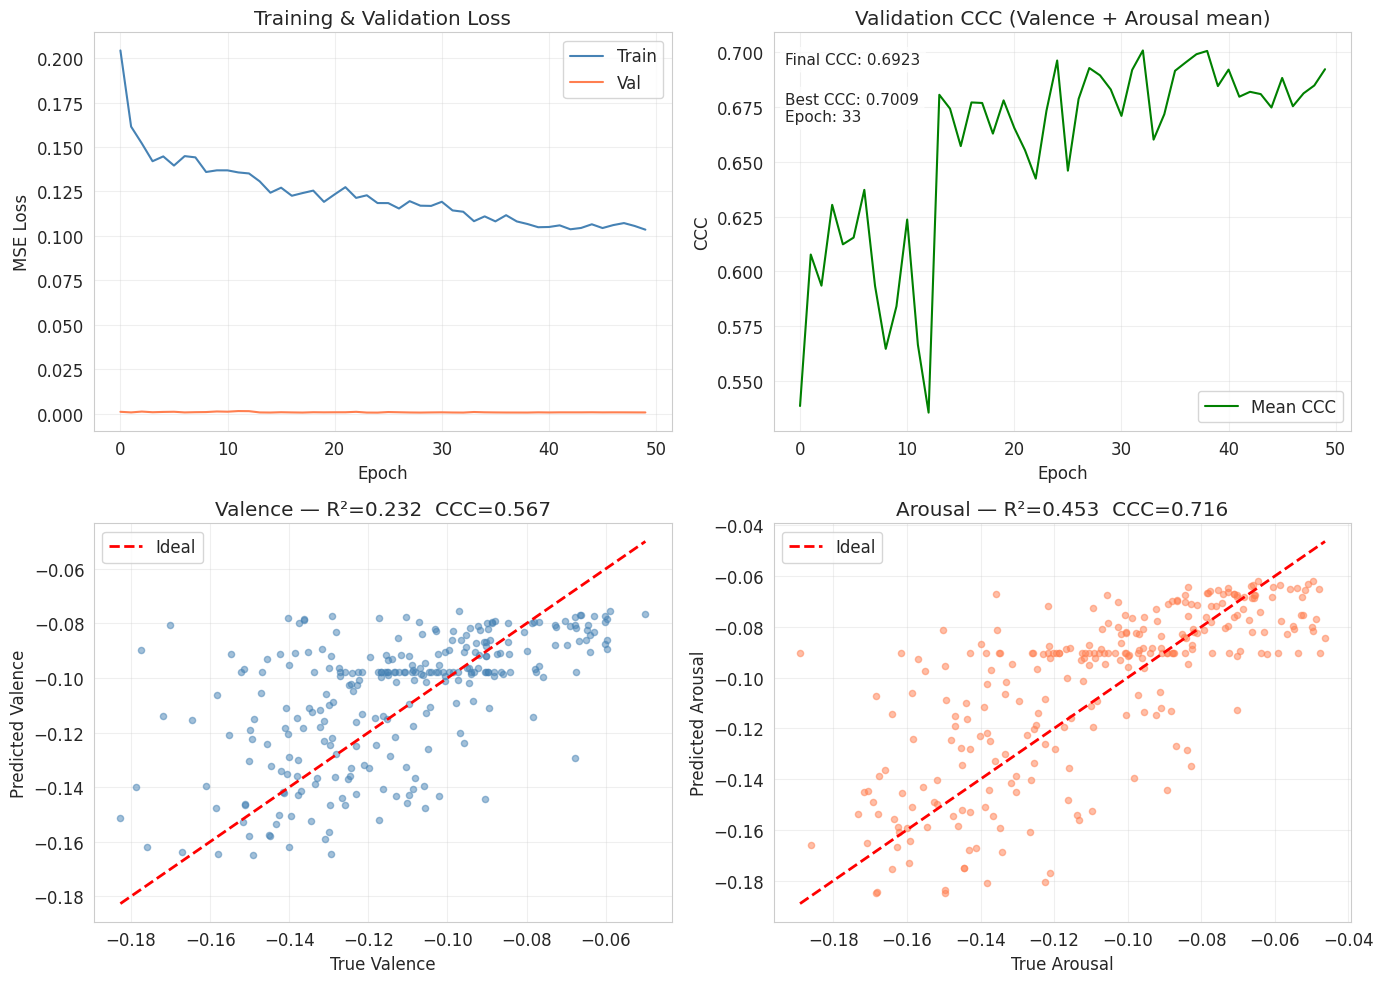

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 \u2014 Loss curves
axes[0, 0].plot(train_losses, label='Train', color='steelblue')
axes[0, 0].plot(val_losses,   label='Val',   color='coral')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2 \u2014 CCC over epochs
axes[0, 1].plot(val_ccc_history, label='Mean CCC', color='green')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('CCC')
axes[0, 1].set_title('Validation CCC (Valence + Arousal mean)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

mean_ccc_final = val_ccc_history[-1]

axes[0, 1].text(
    0.02, 0.95,
    f'Final CCC: {mean_ccc_final:.4f}',
    transform=axes[0, 1].transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

best_ccc = max(val_ccc_history)
best_epoch = val_ccc_history.index(best_ccc) + 1

axes[0, 1].text(
    0.02, 0.85,
    f'Best CCC: {best_ccc:.4f}\nEpoch: {best_epoch}',
    transform=axes[0, 1].transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

# 3 \u2014 Valence scatter
axes[1, 0].scatter(test_targets_arr[:, 0], test_preds[:, 0],
                   alpha=0.5, s=20, color='steelblue')
lo = min(test_targets_arr[:, 0].min(), test_preds[:, 0].min())
hi = max(test_targets_arr[:, 0].max(), test_preds[:, 0].max())
axes[1, 0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal')
axes[1, 0].set_xlabel('True Valence'); axes[1, 0].set_ylabel('Predicted Valence')
axes[1, 0].set_title(f'Valence \u2014 R\u00b2={test_metrics["valence_r2"]:.3f}  '
                      f'CCC={test_metrics["valence_ccc"]:.3f}')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 4 \u2014 Arousal scatter
axes[1, 1].scatter(test_targets_arr[:, 1], test_preds[:, 1],
                   alpha=0.5, s=20, color='coral')
lo = min(test_targets_arr[:, 1].min(), test_preds[:, 1].min())
hi = max(test_targets_arr[:, 1].max(), test_preds[:, 1].max())
axes[1, 1].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal')
axes[1, 1].set_xlabel('True Arousal'); axes[1, 1].set_ylabel('Predicted Arousal')
axes[1, 1].set_title(f'Arousal \u2014 R\u00b2={test_metrics["arousal_r2"]:.3f}  '
                      f'CCC={test_metrics["arousal_ccc"]:.3f}')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


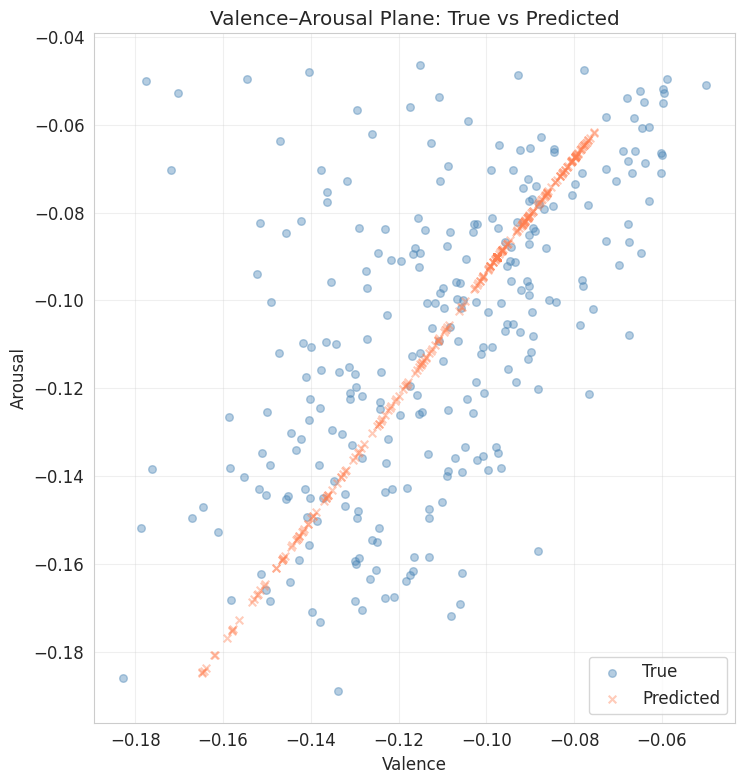

In [16]:
# --- Valence-Arousal plane ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(test_targets_arr[:, 0], test_targets_arr[:, 1],
           alpha=0.4, s=30, label='True', color='steelblue')
ax.scatter(test_preds[:, 0], test_preds[:, 1],
           alpha=0.4, s=30, label='Predicted', color='coral', marker='x')
ax.set_xlabel('Valence'); ax.set_ylabel('Arousal')
ax.set_title('Valence\u2013Arousal Plane: True vs Predicted')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
